# Model B — EfficientNet-B3 멀티뷰 + Concat-MLP (v2)

비교 실험 계획의 **Baseline B** 구현. A(단일뷰)에서 입력만 2장으로 늘린 가장 단순한 멀티뷰 모델.


## 구조
```
앞면 (300×300×3)            뒷면 (300×300×3)
      ↓                            ↓
  EfficientNet-B3 ←── weight 공유 ──→ EfficientNet-B3
      ↓                            ↓
  feature map (1536, 10, 10)   feature map (1536, 10, 10)
      ↓                            ↓
     GAP                          GAP
      ↓                            ↓
   f_a (1536)                   f_b (1536)
        └──────────┬─────────────┘
                  ▼
            Concat (3072)
                  ↓
          MLP (3072 → 512 → 4)
                  ↓
              CORN Loss
                  ↓
         컨디션 1~5점 예측
```

## 핵심 설계
- **Backbone weight 공유**: 같은 EfficientNet-B3 인스턴스를 앞/뒤에 두 번 통과
- **Loss**: CORN (5 classes → 4 binary, ordinal regression)
- **Fusion**: 단순 GAP + Concat (C, D의 baseline)


## 1. Setup

In [1]:
# 필요 시 한 번만 실행
!pip install torch torchvision timm coral-pytorch scikit-learn pandas opencv-python tqdm matplotlib seaborn

In [2]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("PYTHONHASHSEED", os.environ.get("SEED", "42"))

import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as T
import torchvision.transforms.functional as TF

import timm

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Stop here to avoid accidental CPU training. "
        "Check NVIDIA driver/CUDA state before running this notebook."
    )

device = torch.device('cuda:0')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda:0
PyTorch: 2.8.0+cu128
timm: 1.0.27
CUDA available: True
GPU count: 1
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 2. Config

**경로 부분만 본인 환경에 맞게 수정하세요.**

- `PREPROCESSED_DIR`: `preprocessed_ssim09_blur10_300` 폴더 위치 (station1/2/3가 들어 있는 곳)
- `MANIFESTS_DIR`: 동료가 만든 train/val/test CSV가 있는 폴더

나머지 하이퍼파라미터는 비교 실험 계획의 공통 설정 그대로입니다.

In [3]:
class CFG:
    WORKSPACE_ROOT = Path('/workspace')
    MODEL_C_ROOT = WORKSPACE_ROOT / 'mint' / 'model_c'
    PREPROCESSED_DIR = WORKSPACE_ROOT / 'preprocessed_ssim09_blur10_300'
    MANIFESTS_DIR = PREPROCESSED_DIR / 'manifests'
    CHECKPOINT_DIR = MODEL_C_ROOT / 'checkpoints'

    IMG_SIZE      = 300
    NUM_CLASSES   = 5

    MODEL_NAME    = 'C_multiview_efficientnet_b3'
    BACKBONE_NAME = 'efficientnet_b3'
    PRETRAINED    = True
    from huggingface_hub import hf_hub_download
    PRETRAINED_WEIGHTS = Path(
        hf_hub_download(
            repo_id="timm/efficientnet_b3.ra2_in1k",
            filename="model.safetensors"
        )
    )
    FEATURE_DIM   = 1536
    DROPOUT       = 0.3

    BATCH_SIZE    = 64
    NUM_WORKERS   = 4
    WARMUP_EPOCHS = 5
    MAX_EPOCHS    = 100
    PATIENCE      = 10
    BACKBONE_LR   = 3e-5
    HEAD_LR       = 3e-4
    WEIGHT_DECAY  = 2e-4
    GRAD_CLIP     = 1.0
    AMP_ENABLED   = os.environ.get('AMP_ENABLED', '1').lower() in {'1', 'true', 'yes', 'on'}
    AMP_DTYPE     = torch.bfloat16
    RUN_INDEX     = int(os.environ.get('RUN_INDEX', 0))
    SEED          = int(os.environ.get('SEED', 42))
    RUN_NAME      = os.environ.get('RUN_NAME', f'run_{RUN_INDEX + 1:02d}_seed_{SEED}')
    RUN_DIR       = CHECKPOINT_DIR / RUN_NAME

    MEAN          = [0.485, 0.456, 0.406]
    STD           = [0.229, 0.224, 0.225]

CFG.CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CFG.RUN_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass

set_seed(CFG.SEED)

print(f"PREPROCESSED_DIR exists: {CFG.PREPROCESSED_DIR.exists()}")
print(f"MANIFESTS_DIR exists:    {CFG.MANIFESTS_DIR.exists()}")
print(f"CHECKPOINT_DIR:          {CFG.CHECKPOINT_DIR}")
print(f"RUN_DIR:                 {CFG.RUN_DIR}")
print(f"RUN_SEED:                {CFG.SEED}")
print(f"BATCH_SIZE:              {CFG.BATCH_SIZE}")
print(f"AMP_ENABLED:             {CFG.AMP_ENABLED}")
print(f"AMP_DTYPE:               {CFG.AMP_DTYPE}")


PREPROCESSED_DIR exists: True
MANIFESTS_DIR exists:    True
CHECKPOINT_DIR:          /workspace/mint/model_c/checkpoints
RUN_DIR:                 /workspace/mint/model_c/checkpoints/run_01_seed_42
RUN_SEED:                42
BATCH_SIZE:              64
AMP_ENABLED:             True
AMP_DTYPE:               torch.bfloat16


## 3. Manifests 로드 + 경로 재매핑

동료가 만든 CSV 파일들을 읽어 옵니다. CSV 안의 절대 경로는 동료 PC 기준이라 본인 환경에 맞게 다시 매핑해야 합니다.

매핑 원리: `preprocessed_ssim09_blur10_300\` 이후 부분(예: `station1\sep2023\front_xxx.jpg`)만 잘라내서 본인 `PREPROCESSED_DIR`에 붙입니다.

In [4]:
def remap_path(orig_path, new_root, marker='preprocessed_ssim09_blur10_300'):
    """
    동료의 절대 경로를 본인 PC 경로로 재매핑.
    'preprocessed_ssim09_blur10_300\\' 이후 부분만 살리고 앞을 new_root로 교체.
    
    Args:
        orig_path: 원본 경로 문자열
        new_root: 본인 PC의 preprocessed root 경로
        marker: 경로에서 분기점이 되는 폴더명
    
    Returns:
        본인 PC 경로 (str)
    """
    orig = str(orig_path).replace('/', '\\')   # 슬래시 통일
    
    if marker not in orig:
        return orig   # 매칭 안 되면 원본 반환 (이미 상대 경로일 수도)
    
    # marker 이후의 상대 경로 추출 후 현재 OS 경로로 변환
    relative = orig.split(marker, 1)[1].lstrip('\\').lstrip('/')
    relative_parts = [part for part in relative.replace('\\', '/').split('/') if part]
    
    # 본인 root에 붙이기
    return str(Path(new_root).joinpath(*relative_parts))


def load_split_from_manifest(manifests_dir, preprocessed_root, verify_files=True):
    """
    동료가 만든 train/val/test CSV를 읽어 본인 경로로 재매핑.
    
    Args:
        manifests_dir:     CSV 파일들이 있는 폴더
        preprocessed_root: 본인 PC의 preprocessed_ssim09_blur10_300 경로
        verify_files:      True면 실제 파일 존재 여부 확인하고 누락된 것 제외
    
    Returns:
        (df_train, df_val, df_test)
    """
    splits = {}
    
    for split_name in ['train', 'val', 'test']:
        csv_path = manifests_dir / f'{split_name}.csv'
        if not csv_path.exists():
            raise FileNotFoundError(f"{csv_path} 가 없습니다.")
        
        df = pd.read_csv(csv_path)
        print(f"\n[{split_name}] CSV 로드: {len(df)} 행")
        print(f"  컬럼: {list(df.columns)}")
        
        # 경로 재매핑
        df['front_path'] = df['front_path'].apply(lambda p: remap_path(p, preprocessed_root))
        df['back_path']  = df['back_path'].apply(lambda p: remap_path(p, preprocessed_root))
        
        # 파일 존재 확인
        if verify_files:
            before = len(df)
            df = df[df['front_path'].apply(lambda p: Path(p).exists())].copy()
            df = df[df['back_path'].apply(lambda p: Path(p).exists())].copy()
            after = len(df)
            if before != after:
                print(f"  ⚠ 경로 검증: {before} → {after} ({before-after}개 파일 누락)")
            else:
                print(f"  ✓ 모든 파일 존재 확인")
        
        # condition 유효성 한 번 더 확인
        before = len(df)
        df = df[df['condition'].isin([1, 2, 3, 4, 5])].copy()
        if len(df) != before:
            print(f"  ⚠ condition 필터: {before} → {len(df)}")
        
        splits[split_name] = df.reset_index(drop=True)
    
    return splits['train'], splits['val'], splits['test']


# 실행
df_train, df_val, df_test = load_split_from_manifest(
    CFG.MANIFESTS_DIR,
    CFG.PREPROCESSED_DIR,
    verify_files=True,
)

print(f"\n=== Final ===")
print(f"Train: {len(df_train)}")
print(f"Val:   {len(df_val)}")
print(f"Test:  {len(df_test)}")


[train] CSV 로드: 21886 행
  컬럼: ['station', 'month', 'item_id', 'condition', 'split', 'front_path', 'back_path', 'front_src', 'back_src', 'json_path']
  ✓ 모든 파일 존재 확인

[val] CSV 로드: 6253 행
  컬럼: ['station', 'month', 'item_id', 'condition', 'split', 'front_path', 'back_path', 'front_src', 'back_src', 'json_path']
  ✓ 모든 파일 존재 확인

[test] CSV 로드: 3127 행
  컬럼: ['station', 'month', 'item_id', 'condition', 'split', 'front_path', 'back_path', 'front_src', 'back_src', 'json_path']
  ✓ 모든 파일 존재 확인

=== Final ===
Train: 21886
Val:   6253
Test:  3127


In [5]:
# 분포 확인
print("=== Train condition 분포 ===")
print(df_train['condition'].value_counts(normalize=True).sort_index().round(3))
print("\n=== Val condition 분포 ===")
print(df_val['condition'].value_counts(normalize=True).sort_index().round(3))
print("\n=== Test condition 분포 ===")
print(df_test['condition'].value_counts(normalize=True).sort_index().round(3))

print("\n=== Train station 분포 ===")
print(df_train['station'].value_counts())

=== Train condition 분포 ===
condition
1    0.033
2    0.157
3    0.307
4    0.244
5    0.258
Name: proportion, dtype: float64

=== Val condition 분포 ===
condition
1    0.033
2    0.158
3    0.307
4    0.244
5    0.258
Name: proportion, dtype: float64

=== Test condition 분포 ===
condition
1    0.033
2    0.158
3    0.307
4    0.244
5    0.258
Name: proportion, dtype: float64

=== Train station 분포 ===
station
station1    14986
station3     5065
station2     1835
Name: count, dtype: int64


=== Sanity Check ===
item_id:    2024_02_19_14_10_27
condition:  4
station:    station2

front_path: /workspace/preprocessed_ssim09_blur10_300/station2/feb2024/front_2024_02_19_14_10_27.jpg
  exists: True
back_path:  /workspace/preprocessed_ssim09_blur10_300/station2/feb2024/back_2024_02_19_14_10_27.jpg
  exists: True

front image: size=(300, 300), mode=RGB
back image:  size=(300, 300), mode=RGB


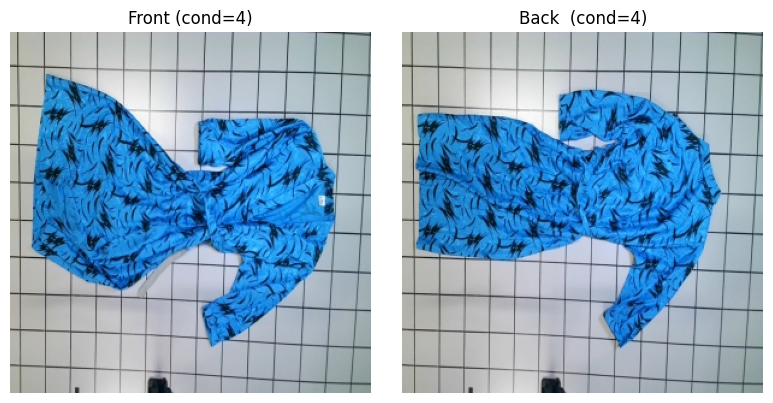

In [6]:
# Sanity check — 첫 행의 파일이 실제로 열리는지 확인
print("=== Sanity Check ===")
sample_row = df_train.iloc[0]
print(f"item_id:    {sample_row['item_id']}")
print(f"condition:  {sample_row['condition']}")
print(f"station:    {sample_row['station']}")
print(f"\nfront_path: {sample_row['front_path']}")
print(f"  exists: {Path(sample_row['front_path']).exists()}")
print(f"back_path:  {sample_row['back_path']}")
print(f"  exists: {Path(sample_row['back_path']).exists()}")

# 실제 이미지 열어보기
try:
    front_img = Image.open(sample_row['front_path'])
    back_img  = Image.open(sample_row['back_path'])
    print(f"\nfront image: size={front_img.size}, mode={front_img.mode}")
    print(f"back image:  size={back_img.size}, mode={back_img.mode}")
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(front_img); axes[0].set_title(f'Front (cond={sample_row["condition"]})'); axes[0].axis('off')
    axes[1].imshow(back_img);  axes[1].set_title(f'Back  (cond={sample_row["condition"]})'); axes[1].axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    print("→ PREPROCESSED_DIR 경로가 맞는지 확인하세요.")

## 4. Dataset 클래스

DataFrame을 직접 받습니다(파일 경로 대신). 페어 augmentation은 앞/뒤에 동일하게 적용 — 이게 깨지면 좌우 대응 학습이 망가집니다.

In [7]:
class GarmentPairDataset(Dataset):
    """
    Front/Back 페어를 한 샘플로 반환.
    
    중요: augmentation(flip, rotate)은 두 이미지에 동일하게 적용해야
    좌우 / 회전 일관성이 유지됨.
    """
    
    def __init__(self, df, img_size=300, mode='train'):
        """
        Args:
            df:       DataFrame with columns [front_path, back_path, condition, ...]
            img_size: 입력 이미지 크기
            mode:     'train' (augmentation 적용) | 'val'/'test' (적용 안 함)
        """
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.mode = mode
        
        self.normalize = T.Normalize(mean=CFG.MEAN, std=CFG.STD)
        # 증강 강화: 일부 영역을 가려 과적합 억제 (train 전용)
        self.random_erase = T.RandomErasing(p=0.25, scale=(0.02, 0.12), value=0.0)
    
    def __len__(self):
        return len(self.df)
    
    def _load(self, path):
        img = Image.open(path).convert('RGB')
        # 전처리에서 이미 300x300이지만 안전망으로 한 번 더 확인
        if img.size != (self.img_size, self.img_size):
            img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        return img
    
    def _paired_train_transform(self, front, back):
        """학습 시 두 이미지에 동일한 augmentation 적용 (paired RandomResizedCrop 추가)"""
        # paired RandomResizedCrop — front/back에 동일 crop 영역 적용
        ci, cj, ch, cw = T.RandomResizedCrop.get_params(
            front, scale=(0.75, 1.0), ratio=(0.9, 1.1)
        )
        front = TF.resized_crop(front, ci, cj, ch, cw, [self.img_size, self.img_size])
        back  = TF.resized_crop(back,  ci, cj, ch, cw, [self.img_size, self.img_size])
        # Random horizontal flip
        if random.random() < 0.5:
            front = TF.hflip(front)
            back  = TF.hflip(back)
        
        # Random rotation (±10도)
        angle = random.uniform(-10, 10)
        front = TF.rotate(front, angle, fill=255)
        back  = TF.rotate(back,  angle, fill=255)
        
        # ColorJitter — 두 이미지에 같은 파라미터로 적용
        b = random.uniform(0.8, 1.2)   # brightness
        c = random.uniform(0.8, 1.2)   # contrast
        s = random.uniform(0.85, 1.15) # saturation
        front = TF.adjust_brightness(front, b)
        back  = TF.adjust_brightness(back,  b)
        front = TF.adjust_contrast(front, c)
        back  = TF.adjust_contrast(back,  c)
        front = TF.adjust_saturation(front, s)
        back  = TF.adjust_saturation(back,  s)
        
        return front, back
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        front = self._load(row['front_path'])
        back  = self._load(row['back_path'])
        
        if self.mode == 'train':
            front, back = self._paired_train_transform(front, back)
        
        front = self.normalize(TF.to_tensor(front))
        back  = self.normalize(TF.to_tensor(back))
        if self.mode == 'train':
            front = self.random_erase(front)
            back  = self.random_erase(back)
        
        # CORN은 0-indexed 라벨 기대 (0~4)
        target = int(row['condition']) - 1
        
        return front, back, target


# Dataset 인스턴스 생성
train_ds = GarmentPairDataset(df_train, CFG.IMG_SIZE, mode='train')
val_ds   = GarmentPairDataset(df_val,   CFG.IMG_SIZE, mode='val')
test_ds  = GarmentPairDataset(df_test,  CFG.IMG_SIZE, mode='val')

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# 샘플 하나 확인
front, back, target = train_ds[0]
print(f"front: {front.shape}, dtype={front.dtype}")
print(f"back:  {back.shape}, dtype={back.dtype}")
print(f"target (0~4): {target}  → condition = {target+1}")

Train: 21886 | Val: 6253 | Test: 3127
front: torch.Size([3, 300, 300]), dtype=torch.float32
back:  torch.Size([3, 300, 300]), dtype=torch.float32
target (0~4): 3  → condition = 4


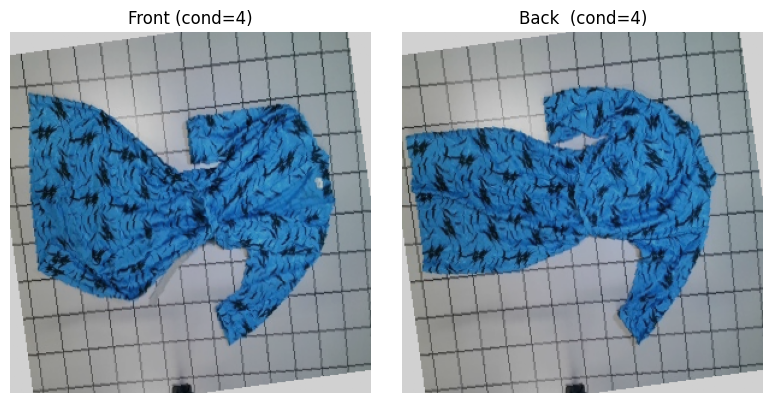

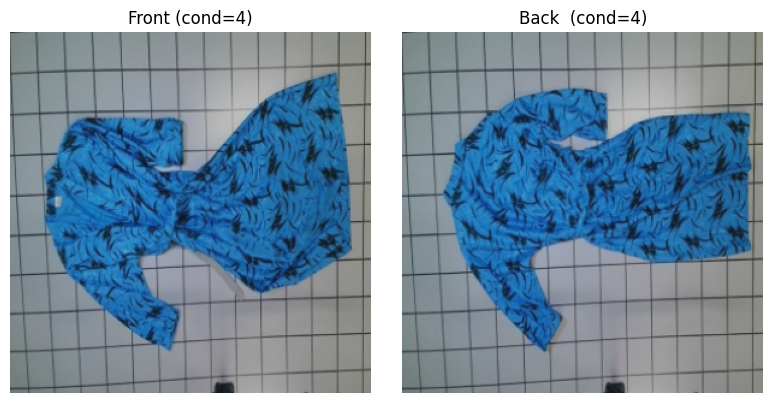

In [8]:
# 시각화로 페어 확인 — augmentation이 두 이미지에 동일하게 적용되는지 눈으로 검증
def show_pair(ds, idx):
    front, back, target = ds[idx]
    mean = torch.tensor(CFG.MEAN).view(3,1,1)
    std  = torch.tensor(CFG.STD).view(3,1,1)
    front_v = (front * std + mean).clamp(0,1).permute(1,2,0).numpy()
    back_v  = (back  * std + mean).clamp(0,1).permute(1,2,0).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(front_v); axes[0].set_title(f'Front (cond={target+1})'); axes[0].axis('off')
    axes[1].imshow(back_v);  axes[1].set_title(f'Back  (cond={target+1})'); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# 같은 인덱스를 여러 번 호출해서 augmentation이 매번 다르게 + 페어 일관성 있는지 확인
for i in range(2):
    show_pair(train_ds, 0)

## 5. Model — EfficientNet-B3 멀티뷰 + Concat

**Backbone weight 공유**가 핵심. `self.backbone` 인스턴스를 하나만 만들고 `forward`에서 두 번 호출합니다.

In [9]:
class ModelC(nn.Module):
    """
    EfficientNet-B3 멀티뷰 + 단순 Concat-MLP.

    Forward:
      front, back: (B, 3, 300, 300)
      → backbone(공유) → (B, 1536, 10, 10) × 2
      → GAP → (B, 1536) × 2
      → Concat → (B, 3072)
      → MLP → (B, 5) logits
    """

    def __init__(self, backbone_name='efficientnet_b3', pretrained=True,
                 feature_dim=1536, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=False,
            num_classes=0,
            global_pool='',
        )
        if pretrained:
            if not CFG.PRETRAINED_WEIGHTS.exists():
                raise FileNotFoundError(f'Pretrained weights not found: {CFG.PRETRAINED_WEIGHTS}')
            from safetensors.torch import load_file
            state_dict = load_file(str(CFG.PRETRAINED_WEIGHTS), device='cpu')
            self.backbone.load_state_dict(state_dict, strict=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Linear(feature_dim * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def extract_features(self, x):
        feat = self.backbone(x)
        feat = self.gap(feat)
        feat = feat.flatten(1)
        return feat

    def forward(self, front, back):
        f_a = self.extract_features(front)
        f_b = self.extract_features(back)
        f_concat = torch.cat([f_a, f_b], dim=1)
        logits = self.head(f_concat)
        return logits

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


model = ModelC(
    backbone_name=CFG.BACKBONE_NAME,
    pretrained=CFG.PRETRAINED,
    feature_dim=CFG.FEATURE_DIM,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT,
).to(device)

with torch.no_grad():
    dummy_f = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(device)
    dummy_b = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(device)
    out = model(dummy_f, dummy_b)
    print(f"Output shape: {out.shape}  (expected: [2, 5])")

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}")
print(f"Trainable: {trainable:,}")


Output shape: torch.Size([2, 5])  (expected: [2, 5])
Total params: 12,272,173
Trainable: 12,272,173


## 6. CORN Loss 및 평가 지표

`coral-pytorch`의 공식 구현을 사용합니다.

In [18]:
def predict(logits):
    return logits.argmax(dim=1)

def compute_metrics(preds, targets):
    preds   = np.asarray(preds,   dtype=np.int64)
    targets = np.asarray(targets, dtype=np.int64)
    return {
        'acc':          float(accuracy_score(targets, preds)),
        'balanced_acc': float(balanced_accuracy_score(targets, preds)),
        'f1_weighted':  float(f1_score(targets, preds, average='weighted', zero_division=0)),
        'f1_macro':     float(f1_score(targets, preds, average='macro',    zero_division=0)),
        'kappa':        float(cohen_kappa_score(targets, preds)),
        'qwk':          float(cohen_kappa_score(targets, preds, weights='quadratic')),
        'mae':          float(np.mean(np.abs(preds - targets))),
    }

# 클래스 불균형 대응: train 분포로 class weight 계산 (balanced / inverse-frequency)
_class_counts = df_train['condition'].astype(int).value_counts().sort_index()
_counts = np.array([_class_counts.get(c, 0) for c in range(1, CFG.NUM_CLASSES + 1)], dtype=np.float64)
_class_weights = _counts.sum() / (CFG.NUM_CLASSES * np.clip(_counts, 1, None))
_class_weights = torch.tensor(_class_weights, dtype=torch.float32, device=device)
print(f"class counts:  {_counts.astype(int).tolist()}")
print(f"class weights: {_class_weights.cpu().numpy().round(3).tolist()}")

# weighted CE + 약한 label smoothing (소수 클래스 학습 + 과적합 완화)
criterion = nn.CrossEntropyLoss(weight=_class_weights, label_smoothing=0.05)

# smoke test
fake_logits = torch.randn(4, 5)
fake_target = torch.tensor([0, 2, 4, 1])
loss = criterion(fake_logits.to(device), fake_target.to(device))
preds_smoke = predict(fake_logits)
print(f"loss smoke: {loss.item():.4f}")
print(f"pred smoke: {preds_smoke.tolist()}")
print(f"metric smoke: {compute_metrics(preds_smoke, fake_target)}")


class counts:  [730, 3447, 6721, 5332, 5656]
class weights: [5.995999813079834, 1.2699999809265137, 0.6510000228881836, 0.8209999799728394, 0.7739999890327454]
loss smoke: 2.2843
pred smoke: [1, 2, 2, 1]
metric smoke: {'acc': 0.5, 'balanced_acc': 0.5, 'f1_weighted': 0.3333333333333333, 'f1_macro': 0.3333333333333333, 'kappa': 0.33333333333333337, 'qwk': 0.6666666666666667, 'mae': 0.75}


## 7. 학습 / 검증 함수

In [11]:
def train_one_epoch(model, loader, optimizer, epoch_idx):
    model.train()
    total_loss = 0.0
    n_samples = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch_idx} [train]", leave=False)
    for front, back, target in pbar:
        front  = front.to(device, non_blocking=True)
        back   = back.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG.AMP_ENABLED, dtype=CFG.AMP_DTYPE):
            logits = model(front, back)
            loss = criterion(logits, target)

        if not torch.isfinite(loss):
            print("Non-finite train loss detected")
            print("target min/max:", target.min().item(), target.max().item())
            print("logits min/max:", logits.detach().min().item(), logits.detach().max().item())
            raise RuntimeError("NaN/Inf train loss")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.GRAD_CLIP)
        optimizer.step()

        with torch.no_grad():
            preds = predict(logits)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

        total_loss += loss.item() * front.size(0)
        n_samples += target.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / n_samples
    metrics = compute_metrics(np.concatenate(all_preds), np.concatenate(all_targets))
    metrics['loss'] = avg_loss
    return metrics


@torch.no_grad()
def evaluate(model, loader, desc='val'):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_preds, all_targets = [], []

    for front, back, target in tqdm(loader, desc=f"[{desc}]", leave=False):
        front  = front.to(device, non_blocking=True)
        back   = back.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        with autocast(enabled=CFG.AMP_ENABLED, dtype=CFG.AMP_DTYPE):
            logits = model(front, back)
            loss = criterion(logits, target)

        if not torch.isfinite(loss):
            print("Non-finite validation loss detected")
            print("target min/max:", target.min().item(), target.max().item())
            print("logits min/max:", logits.detach().min().item(), logits.detach().max().item())
            raise RuntimeError("NaN/Inf validation loss")

        preds = predict(logits)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(target.cpu().numpy())
        total_loss += loss.item() * front.size(0)
        n_samples += target.size(0)

    avg_loss = total_loss / n_samples
    metrics = compute_metrics(np.concatenate(all_preds), np.concatenate(all_targets))
    metrics['loss'] = avg_loss
    return metrics, np.concatenate(all_preds), np.concatenate(all_targets)


## 8. 메인 학습 루프

**2-Stage 전략**:
- Stage 1 (Warmup, 3 epoch): backbone freeze, head만 학습
  - 랜덤 init된 head가 backbone을 망가뜨리는 것 방지
- Stage 2 (Full fine-tuning, 최대 97 epoch): backbone unfreeze, 차등 lr
  - backbone lr=1e-4, head lr=1e-3 (10배 차이)
  - val MAE 5 epoch 동안 개선 없으면 early stop

In [12]:
def seed_worker(worker_id):
    worker_seed = CFG.SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(CFG.SEED)

train_loader = DataLoader(
    train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=(CFG.NUM_WORKERS > 0),
    worker_init_fn=seed_worker, generator=loader_generator,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True,
    persistent_workers=(CFG.NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True,
    persistent_workers=(CFG.NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
)

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG.BACKBONE_LR},
    {'params': model.head.parameters(),     'lr': CFG.HEAD_LR},
], weight_decay=CFG.WEIGHT_DECAY)

# LR이 거의 안 떨어지던 문제 수정: val_loss plateau에 반응해 lr을 절반씩 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6,
)


print(f"학습 준비 완료 (device={device})")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")


학습 준비 완료 (device=cuda:0)
Train batches: 341
Val batches:   98


In [13]:
history = {'train': [], 'val': []}
best_val_loss = float('inf')
patience_counter = 0
best_epoch = -1
best_path = CFG.RUN_DIR / f'best_{CFG.MODEL_NAME}.pt'

def _save_best(epoch, val_m):
    global best_val_loss, best_epoch, patience_counter
    if np.isfinite(val_m['loss']) and val_m['loss'] < best_val_loss:
        best_val_loss, best_epoch, patience_counter = val_m['loss'], epoch, 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'val_metrics': val_m,
                    'config': {k: str(v) for k, v in vars(CFG).items() if not k.startswith('_')}},
                   best_path)
        print(f'  Best updated (Loss {best_val_loss:.4f})')
    else:
        patience_counter += 1
        if not np.isfinite(val_m['loss']):
            print('  Skipped checkpoint: non-finite validation metric')

print('=' * 60)
print('Stage 1: Warmup - backbone freeze, head only')
print('=' * 60)
model.freeze_backbone()

for epoch in range(CFG.WARMUP_EPOCHS):
    train_m = train_one_epoch(model, train_loader, optimizer, epoch)
    val_m, _, _ = evaluate(model, val_loader, desc='val')
    history['train'].append({'epoch': epoch, **train_m})
    history['val'].append({'epoch': epoch, **val_m})
    print(f'[Warmup {epoch+1}/{CFG.WARMUP_EPOCHS}] '
          f'train_loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} | '
          f'val_loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} f1={val_m["f1_weighted"]:.3f}')
    _save_best(epoch, val_m)

print('\n' + '=' * 60)
print('Stage 2: Full fine-tuning - backbone unfreeze')
print('=' * 60)
model.unfreeze_backbone()
patience_counter = 0

for epoch in range(CFG.WARMUP_EPOCHS, CFG.MAX_EPOCHS):
    train_m = train_one_epoch(model, train_loader, optimizer, epoch)
    val_m, _, _ = evaluate(model, val_loader, desc='val')
    scheduler.step(val_m['loss'])
    history['train'].append({'epoch': epoch, **train_m})
    history['val'].append({'epoch': epoch, **val_m})
    cur_lr_b = optimizer.param_groups[0]['lr']
    cur_lr_h = optimizer.param_groups[1]['lr']
    print(f'[Epoch {epoch+1}/{CFG.MAX_EPOCHS}] '
          f'train_loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} | '
          f'val_loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} '
          f'f1={val_m["f1_weighted"]:.3f} kappa={val_m["kappa"]:.3f} | '
          f'lr_b={cur_lr_b:.2e} lr_h={cur_lr_h:.2e}')
    _save_best(epoch, val_m)
    if patience_counter >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {CFG.PATIENCE} epochs)')
        break

print(f'\n학습 완료. Best epoch: {best_epoch+1}, Best val Loss: {best_val_loss:.4f}')


Stage 1: Warmup — backbone freeze, head only


Epoch 0 [train]:   0%|          | 0/341 [00:00<?, ?it/s]

[val]:   0%|          | 0/98 [00:00<?, ?it/s]

[Warmup 1/5] train_loss=1.6403 acc=0.229 | val_loss=1.7789 acc=0.264 f1=0.264
  Best updated (Loss 1.7789)


Epoch 1 [train]:   0%|          | 0/341 [00:00<?, ?it/s]

...

[val]:   0%|          | 0/98 [00:00<?, ?it/s]

[Epoch 16/100] train_loss=1.1369 acc=0.558 | val_loss=1.7666 acc=0.329 f1=0.334 kappa=0.145 | lr_b=3.75e-06 lr_h=3.75e-05


Epoch 16 [train]:   0%|          | 0/341 [00:00<?, ?it/s]

[val]:   0%|          | 0/98 [00:00<?, ?it/s]

[Epoch 17/100] train_loss=1.1107 acc=0.570 | val_loss=2.0683 acc=0.338 f1=0.344 kappa=0.147 | lr_b=3.75e-06 lr_h=3.75e-05

Early stopping at epoch 17 (no improvement for 10 epochs)

학습 완료. Best epoch: 7, Best val Loss: 1.6128


## 9. Test 평가

Best checkpoint를 로드해서 test set으로 최종 성능을 측정합니다.

KeyError: 'mae'

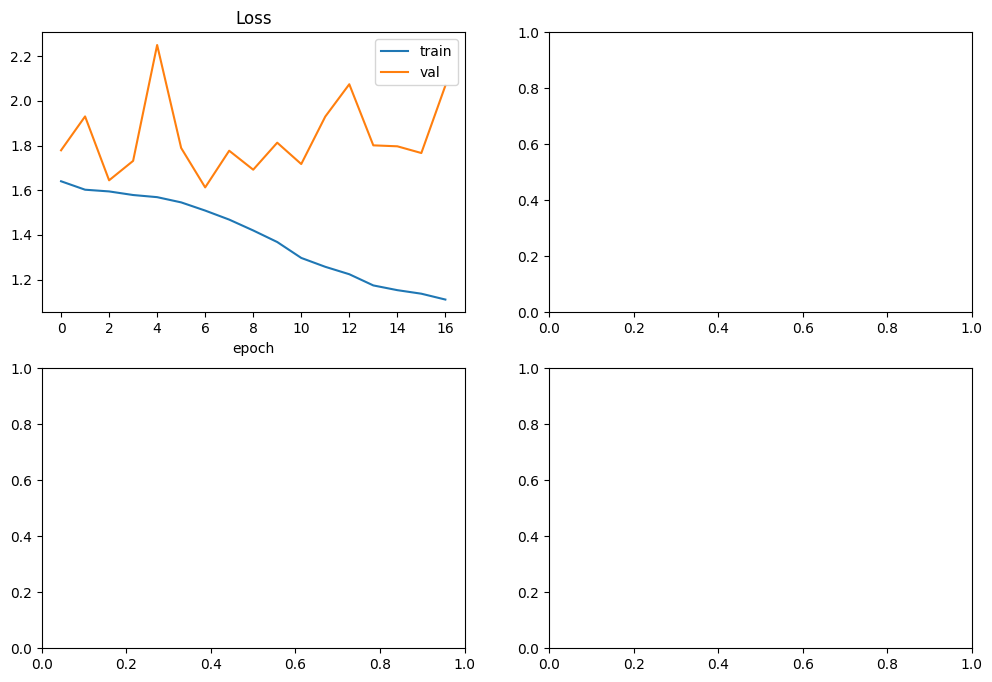

In [17]:
hist_train = pd.DataFrame(history['train'])
hist_val   = pd.DataFrame(history['val'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(hist_train['epoch'], hist_train['loss'], label='train')
axes[0,0].plot(hist_val['epoch'],   hist_val['loss'],   label='val')
axes[0,0].set_title('Loss'); axes[0,0].set_xlabel('epoch'); axes[0,0].legend()

axes[0,1].plot(hist_train['epoch'], hist_train['mae'], label='train')
axes[0,1].plot(hist_val['epoch'],   hist_val['mae'],   label='val')
axes[0,1].set_title('MAE'); axes[0,1].set_xlabel('epoch'); axes[0,1].legend()

axes[1,0].plot(hist_train['epoch'], hist_train['acc'], label='train')
axes[1,0].plot(hist_val['epoch'],   hist_val['acc'],   label='val')
axes[1,0].set_title('Accuracy'); axes[1,0].set_xlabel('epoch'); axes[1,0].legend()

axes[1,1].plot(hist_train['epoch'], hist_train['qwk'], label='train')
axes[1,1].plot(hist_val['epoch'],   hist_val['qwk'],   label='val')
axes[1,1].set_title('Quadratic Weighted Kappa'); axes[1,1].set_xlabel('epoch'); axes[1,1].legend()

plt.tight_layout()
plt.show()

In [19]:
ckpt = torch.load(CFG.RUN_DIR / f'best_{CFG.MODEL_NAME}.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']+1}")
print(f"Saved val metrics: {ckpt['val_metrics']}")

test_metrics, test_preds, test_targets = evaluate(model, test_loader, desc='test')

print("\n=== Test Metrics ===")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

pd.DataFrame(history['train']).to_csv(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_history_train.csv', index=False)
pd.DataFrame(history['val']).to_csv(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_history_val.csv', index=False)
cm = confusion_matrix(test_targets, test_preds, labels=[0, 1, 2, 3, 4])
pd.DataFrame(cm, index=[1,2,3,4,5], columns=[1,2,3,4,5]).to_csv(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_confusion.csv')


Loaded best checkpoint from epoch 7
Saved val metrics: {'acc': 0.3147289301135455, 'balanced_acc': 0.3199469236341524, 'f1_weighted': 0.3114645924880702, 'f1_macro': 0.2793450654315123, 'kappa': 0.1397683464373084, 'loss': 1.6128292172389393}


[test]:   0%|          | 0/49 [00:00<?, ?it/s]


=== Test Metrics ===
  acc: 0.3252
  balanced_acc: 0.3334
  f1_weighted: 0.3218
  f1_macro: 0.2899
  kappa: 0.1511
  qwk: 0.2139
  mae: 1.2085
  loss: 2.0543


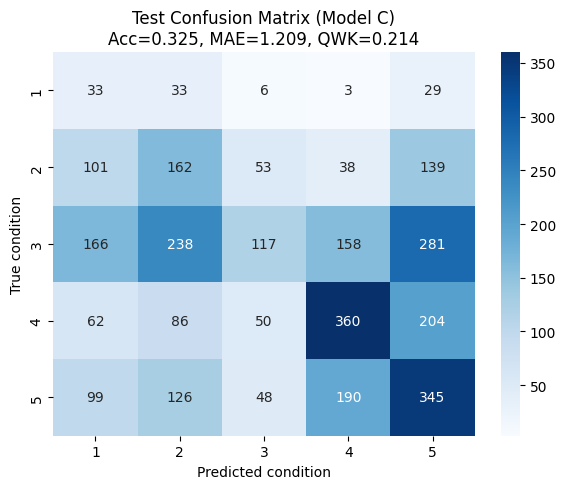

In [20]:
# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds, labels=[0,1,2,3,4])
class_names = ['1', '2', '3', '4', '5']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted condition')
plt.ylabel('True condition')
plt.title(f'Test Confusion Matrix (Model C)\n'
          f'Acc={test_metrics["acc"]:.3f}, MAE={test_metrics["mae"]:.3f}, '
          f'QWK={test_metrics["qwk"]:.3f}')
plt.tight_layout()
plt.show()

In [21]:
result = {
    'model': CFG.MODEL_NAME,
    'backbone': CFG.BACKBONE_NAME,
    'run_name': CFG.RUN_NAME,
    'seed': int(CFG.SEED),
    'config': {k: str(v) for k, v in vars(CFG).items() if not k.startswith('_')},
    'best_epoch': int(ckpt['epoch']),
    'val_metrics': {k: float(v) for k, v in ckpt['val_metrics'].items()},
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'data': {
        'n_train': len(df_train),
        'n_val':   len(df_val),
        'n_test':  len(df_test),
    },
    'env': {
        'torch': torch.__version__,
        'timm': timm.__version__,
        'gpu': torch.cuda.get_device_name(0),
    },
}

with open(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_result.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print("결과 저장 완료:", CFG.RUN_DIR / f'{CFG.MODEL_NAME}_result.json')
print(json.dumps(result, indent=2, ensure_ascii=False))


결과 저장 완료: /workspace/mint/model_c/checkpoints/run_01_seed_42/C_multiview_efficientnet_b3_result.json
{
  "model": "C_multiview_efficientnet_b3",
  "backbone": "efficientnet_b3",
  "run_name": "run_01_seed_42",
  "seed": 42,
  "config": {
    "WORKSPACE_ROOT": "/workspace",
    "MODEL_C_ROOT": "/workspace/mint/model_c",
    "PREPROCESSED_DIR": "/workspace/preprocessed_ssim09_blur10_300",
    "MANIFESTS_DIR": "/workspace/preprocessed_ssim09_blur10_300/manifests",
    "CHECKPOINT_DIR": "/workspace/mint/model_c/checkpoints",
    "IMG_SIZE": "300",
    "NUM_CLASSES": "5",
    "MODEL_NAME": "C_multiview_efficientnet_b3",
    "BACKBONE_NAME": "efficientnet_b3",
    "PRETRAINED": "True",
    "hf_hub_download": "<function hf_hub_download at 0x7824c887e200>",
    "PRETRAINED_WEIGHTS": "/workspace/.cache/huggingface/hub/models--timm--efficientnet_b3.ra2_in1k/snapshots/0366a75518620e0f2077789202073759f2d61393/model.safetensors",
    "FEATURE_DIM": "1536",
    "DROPOUT": "0.3",
    "BATCH_SIZE": "6